<a href="https://colab.research.google.com/github/21anirudh/Data-Preprocessing-And-Feature-Engineering/blob/main/Data_Preprocessing_And_Feature_Engineering3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import load_iris

In [ ]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

In [ ]:
print(df.shape)
print(df.head())

(150, 5)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


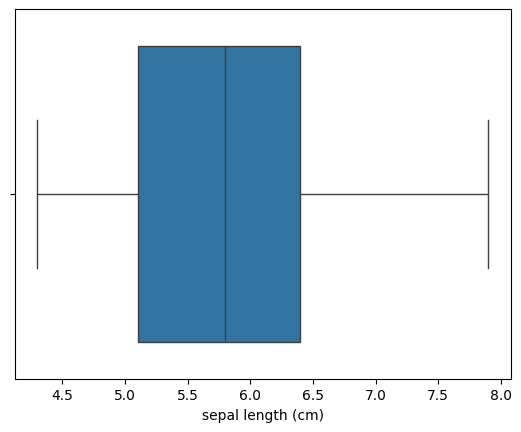

In [ ]:
sns.boxplot(x=df["sepal length (cm)"])
plt.show()

In [ ]:
# Inter Quartile Range - Measure of spread of dataset
q1 = df["sepal length (cm)"].quantile(0.25)
q3 = df["sepal length (cm)"].quantile(0.75)
iqr = q3 - q1
up = q3 + 1.5 * iqr
low = q1 - 1.5 * iqr

In [ ]:
# Finding the Outliers
print(df[(df["sepal length (cm)"] < low) | (df["sepal length (cm)"] > up)].any(axis=None))
print(df[(df["sepal length (cm)"] < low)].any(axis=None))
print(df[(df["sepal length (cm)"] < low) | (df["sepal length (cm)"] > up)])
print(df[(df["sepal length (cm)"] < low) | (df["sepal length (cm)"] > up)].index)

False
False
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), species]
Index: []
Index([], dtype='int64')


In [ ]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O" and col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f"cat_cols: {len(cat_cols)}")
    print(f"num_cols: {len(num_cols)}")
    print(f"cat_but_car: {len(cat_but_car)}")
    print(f"num_but_cat: {len(num_but_cat)}")

    return cat_cols, num_cols, cat_but_car

cat_cols, num_cols, cat_but_car = grab_col_names(df)

print(num_cols)

Observations: 150
Variables: 5
cat_cols: 1
num_cols: 4
cat_but_car: 0
num_but_cat: 1
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [ ]:
# Checking outliers in numerical columns of df
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    up = q3 + 1.5 * iqr
    low = q1 - 1.5 * iqr
    print(col, df[(df[col] < low) | (df[col] > up)].any(axis=None))

def grab_outliers(dataframe, col_name, outlier_index=False, f=5):
    quartile1 = dataframe[col_name].quantile(0.25)
    quartile3 = dataframe[col_name].quantile(0.75)
    interquantile_range = quartile3 - quartile1
    up = quartile3 + 1.5 * interquantile_range
    low = quartile1 - 1.5 * interquantile_range

    if dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].shape[0] > 10:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].head(f))
    else:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))])

    if outlier_index:
        out_index = dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].index
        return out_index

sepal_length_index = grab_outliers(df, "sepal length (cm)", True)
print(sepal_length_index)

sepal length (cm) False
sepal width (cm) True
petal length (cm) False
petal width (cm) False
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), species]
Index: []
Index([], dtype='int64')


In [ ]:
# Removing Outliers
def remove_outlier(dataframe, col_name):
    quartile1 = dataframe[col_name].quantile(0.25)
    quartile3 = dataframe[col_name].quantile(0.75)
    interquantile_range = quartile3 - quartile1
    up = quartile3 + 1.5 * interquantile_range
    low = quartile1 - 1.5 * interquantile_range
    df_without_outliers = dataframe[~((dataframe[col_name] < low) | (dataframe[col_name] > up))]
    return df_without_outliers

cat_cols, num_cols, cat_but_car = grab_col_names(df)

for col in num_cols:
    df = remove_outlier(df, col)

print(df.shape)

Observations: 150
Variables: 5
cat_cols: 1
num_cols: 4
cat_but_car: 0
num_but_cat: 1
(146, 5)


In [ ]:
def replace_with_thresholds(dataframe, variable):
    quartile1 = dataframe[variable].quantile(0.25)
    quartile3 = dataframe[variable].quantile(0.75)
    interquantile_range = quartile3 - quartile1
    up = quartile3 + 1.5 * interquantile_range
    low = quartile1 - 1.5 * interquantile_range
    dataframe.loc[(dataframe[variable] < low), variable] = low
    dataframe.loc[(dataframe[variable] > up), variable] = up

cat_cols, num_cols, cat_but_car = grab_col_names(df)

for col in num_cols:
    replace_with_thresholds(df, col)

for col in num_cols:
    print(col, print(df[(df[col] < low) | (df[col] > up)].any(axis=None)))

Observations: 146
Variables: 5
cat_cols: 1
num_cols: 4
cat_but_car: 0
num_but_cat: 1
True
sepal length (cm) None
False
sepal width (cm) None
True
petal length (cm) None
False
petal width (cm) None


In [ ]:
df = df.select_dtypes(include=['float64', 'int64'])
df = df.dropna()
clf = LocalOutlierFactor(n_neighbors=20)
clf.fit_predict(df)
df_scores = clf.negative_outlier_factor_
print(df_scores)

[-0.97772356 -1.0129498  -1.02414083 -1.05593645 -0.96389131 -1.17623286
 -1.01969128 -0.96278064 -1.19431941 -0.96497236 -1.04227923 -0.96147716
 -1.02969505 -1.32568723 -1.603737   -1.17360991 -0.98002764 -1.31213936
 -1.00919058 -1.03849591 -1.01422597 -1.27218059 -0.99029429 -1.07111698
 -0.98420295 -0.97405478 -0.98250387 -0.97820414 -1.01705429 -0.99933147
 -1.00583204 -0.96932413 -0.97586371 -1.09900046 -0.94641109 -1.16500566
 -0.97700545 -0.95389627 -1.77758216 -1.13501613 -1.0113078  -1.14974109
 -1.02768993 -1.01354106 -1.04843866 -1.02893309 -0.96662649 -1.18214688
 -1.02636039 -1.14092364 -1.01876254 -1.0332014  -0.94175696 -1.0331743
 -1.46463788 -1.03411943 -1.02370171 -0.94164588 -1.06568516 -0.99454865
 -1.03035725 -1.04425952 -0.98374165 -0.9883527  -1.10026036 -0.9996217
 -1.06349891 -0.96179371 -1.04055533 -0.98870438 -0.98637842 -1.02309519
 -1.06238865 -1.10391296 -0.96904273 -1.11210125 -1.05823391 -1.10272605
 -0.9900477  -1.06894864 -1.02153504 -1.00867941 -1.0

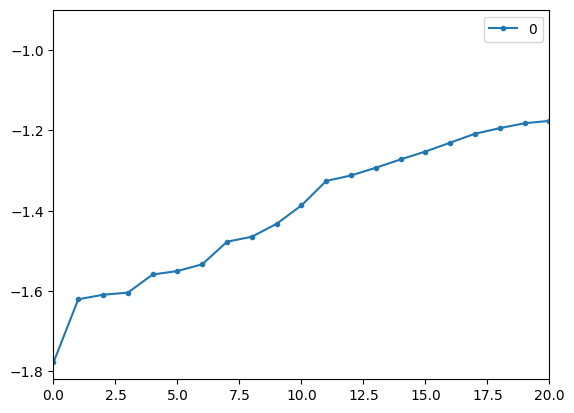

In [ ]:
scores = pd.DataFrame(np.sort(df_scores))
scores.plot(stacked=True, xlim=[0, 20], style='.-')
plt.show()

In [ ]:
threshold = np.sort(df_scores)[12]  # Assuming, graph becomes stable at 12th point. Although, to me it appears to be stable even after 2nd.
print(df[df_scores < threshold])

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
13                 4.3               3.0                1.1               0.1   
14                 5.8               4.0                1.2               0.2   
41                 4.5               2.3                1.3               0.3   
57                 4.9               2.4                3.3               1.0   
93                 5.0               2.3                3.3               1.0   
98                 5.1               2.5                3.0               1.1   
105                7.6               3.0                6.6               2.1   
106                4.9               2.5                4.5               1.7   
117                7.7               3.8                6.7               2.2   
118                7.7               2.6                6.9               2.3   
122                7.7               2.8                6.7               2.0   
131                7.9      

In [ ]:
print(df.drop(axis=0, labels=df[df_scores < threshold].index).shape)

(134, 5)
